<a href="https://colab.research.google.com/github/viictorsauraa/EML/blob/main/bandit_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estudio comparativo de algoritmos en un problema de k-armed bandit con brazos de distribución normal

*Description:* El experimento compara el rendimiento de algoritmos en un problema de k-armed bandit con brazos de distribución normal.
Se generan gráficas explicativas de cada algoritmo.

    Author: Luis Daniel Hernández Molinero
    Email: ldaniel@um.es
    Date: 2025/01/29

This software is licensed under the GNU General Public License v3.0 (GPL-3.0),
with the additional restriction that it may not be used for commercial purposes.

For more details about GPL-3.0: https://www.gnu.org/licenses/gpl-3.0.html



## Preparación del entorno


In [1]:
#@title Copiar el repositorio.
import os

# !git clone https://github.com/ldaniel-hm/eml_k_bandit.git
# !git clone https://github.com/viictorsauraa/EML.git
# Verificar si el directorio ya existe
if not os.path.exists('eml_k_bandit'):
    !wget "https://univmurcia-my.sharepoint.com/:u:/g/personal/victor_sauram_um_es/IQAvPbPW9nqgSLYdK7zs5TrvAX25BUAM3moIGMjGyyQ-FVI?download=1" -O eml_k_bandit.zip
    !unzip -q eml_k_bandit.zip
    !rm eml_k_bandit.zip
else:
    print("El directorio 'eml_k_bandit' ya existe, omitiendo descarga")

# Cambiar al directorio
%cd eml_k_bandit/

--2026-02-13 11:07:44--  https://univmurcia-my.sharepoint.com/:u:/g/personal/victor_sauram_um_es/IQAvPbPW9nqgSLYdK7zs5TrvAX25BUAM3moIGMjGyyQ-FVI?download=1
Resolving univmurcia-my.sharepoint.com (univmurcia-my.sharepoint.com)... 13.107.136.10, 13.107.138.10, 2620:1ec:8f8::10, ...
Connecting to univmurcia-my.sharepoint.com (univmurcia-my.sharepoint.com)|13.107.136.10|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: /personal/victor_sauram_um_es/Documents/(EML)%20Extensiones%20de%20Machine%20Learning/eml_k_bandit.zip?ga=1 [following]
--2026-02-13 11:07:44--  https://univmurcia-my.sharepoint.com/personal/victor_sauram_um_es/Documents/(EML)%20Extensiones%20de%20Machine%20Learning/eml_k_bandit.zip?ga=1
Reusing existing connection to univmurcia-my.sharepoint.com:443.
HTTP request sent, awaiting response... 200 OK
Length: 459041 (448K) [application/x-zip-compressed]
Saving to: ‘eml_k_bandit.zip’

eml_k_bandit.zip    100%[===================>] 448.28K  1.24MB/s   

In [1]:
#@title Importamos todas las clases y funciones

import sys

# Añadir los directorio fuentes al path de Python
#sys.path.append('/content/eml_k_bandit')


# Verificar que se han añadido correctamente
#print(sys.path)

import numpy as np
from typing import List

from algorithms import Algorithm, EpsilonGreedy, EpsilonDecaimiento, Softmax, UCB1
from arms import ArmNormal, Bandit
from plotting import (
    plot_average_rewards,
    plot_optimal_selections,
    plot_regret,
    plot_arm_statistics
)

## Experimento

Cada algoritmo se ejecuta en un problema de k-armed bandit durante un número de pasos de tiempo y ejecuciones determinado.
Se comparan los resultados de los algoritmos en términos de recompensa promedio.

Por ejemplo. Dado un bandido de k-brazos, se ejecutan dos algoritmos epsilon-greedy con diferentes valores de epsilon. Se estudia la evolución de cada política  en un número de pasos, por ejemplo, mil pasos. Entonces se repite el experimento un número de veces, por ejemplo, 500 veces. Es decir, se ejecutan 500 veces la evolución de cada algoritmo en 1000 pasos. Para cada paso calculamos el promedio de las recoponensas obtenidas en esas 500 veces.

In [3]:

seed = 42

def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):

    optimal_arm = bandit.optimal_arm  # Necesario para calcular el porcentaje de selecciones óptimas.

    optimal_reward = bandit.arms[optimal_arm].get_expected_value()  # Recompensa del brazo óptimo
    n_arms = len(bandit.arms)
    n_algos = len(algorithms)

    rewards = np.zeros((len(algorithms), steps)) # Matriz para almacenar las recompensas promedio.

    optimal_selections = np.zeros((len(algorithms), steps))  # Matriz para almacenar el porcentaje de selecciones óptimas.

    # Matriz para almacenar el regret
    regret = np.zeros((n_algos, steps))

    # Estadísticas de brazos (acumuladores)
    arm_selections = np.zeros((n_algos, n_arms))
    arm_total_rewards = np.zeros((n_algos, n_arms))

    np.random.seed(seed)  # Asegurar reproducibilidad de resultados.

    for run in range(runs):
        current_bandit = Bandit(arms=bandit.arms)

        for algo in algorithms:
            algo.reset() # Reiniciar los valores de los algoritmos.

        total_rewards_per_algo = np.zeros(len(algorithms)) # Acumulador de recompensas por algoritmo. Necesario para calcular el promedio.

        for step in range(steps):
            for idx, algo in enumerate(algorithms):
                chosen_arm = algo.select_arm() # Seleccionar un brazo según la política del algoritmo.
                reward = current_bandit.pull_arm(chosen_arm) # Obtener la recompensa del brazo seleccionado.
                algo.update(chosen_arm, reward) # Actualizar el valor estimado del brazo seleccionado.

                rewards[idx, step] += reward # Acumular la recompensa obtenida en la matriz rewards para el algoritmo idx en el paso step.
                total_rewards_per_algo[idx] += reward # Acumular la recompensa obtenida en total_rewards_per_algo para el algoritmo idx.

                #TODO: modificar optimal_selections cuando el brazo elegido se corresponda con el brazo óptimo optimal_arm
                # Actualizar optimal_selections cuando el brazo elegido es el óptimo
                if chosen_arm == optimal_arm:
                    optimal_selections[idx, step] += 1

                # Calcular regret instantáneo
                instant_regret = optimal_reward - reward
                regret[idx, step] += instant_regret

                # Estadísticas de brazos
                arm_selections[idx, chosen_arm] += 1
                arm_total_rewards[idx, chosen_arm] += reward


    rewards /= runs

    # TODO: calcular el porcentaje de selecciones óptimas y almacenar en optimal_selections

    # Calcular el porcentaje de selecciones óptimas
    optimal_selections = (optimal_selections / runs) * 100  # Convertir a porcentaje

    # Calcular regret acumulado
    regret /= runs
    regret_accumulated = np.cumsum(regret, axis=1)  # Acumular el regret paso a paso

    # Calcular estadísticas de brazos
    arm_stats = []
    for algo_idx in range(n_algos):
        mean_rewards = np.zeros(n_arms)
        for arm_idx in range(n_arms):
            if arm_selections[algo_idx, arm_idx] > 0:
                mean_rewards[arm_idx] = arm_total_rewards[algo_idx, arm_idx] / arm_selections[algo_idx, arm_idx]

        arm_stats.append({
            'mean_rewards': mean_rewards,
            'selections': arm_selections[algo_idx],
            'total_rewards': arm_total_rewards[algo_idx]
        })

    return rewards, optimal_selections, regret_accumulated, arm_stats


## Experimento con epsilon-greedy

In [21]:

# Parámetros del experimento
np.random.seed(seed)  # Fijar la semilla para reproducibilidad

k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Creación del bandit
bandit = Bandit(arms=ArmNormal.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [EpsilonGreedy(k=k, epsilon=0), EpsilonGreedy(k=k, epsilon=0.01), EpsilonGreedy(k=k, epsilon=0.1)]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections, regret_accumulated, arm_stats = run_experiment(bandit, algorithms, steps, runs)


Bandit with 10 arms: ArmNormal(mu=1.52, sigma=1.0), ArmNormal(mu=2.4, sigma=1.0), ArmNormal(mu=1.19, sigma=1.0), ArmNormal(mu=4.37, sigma=1.0), ArmNormal(mu=6.39, sigma=1.0), ArmNormal(mu=7.59, sigma=1.0), ArmNormal(mu=8.8, sigma=1.0), ArmNormal(mu=9.56, sigma=1.0), ArmNormal(mu=6.41, sigma=1.0), ArmNormal(mu=7.37, sigma=1.0)
Optimal arm: 8 with expected reward=9.56


### Visualización de los resultados

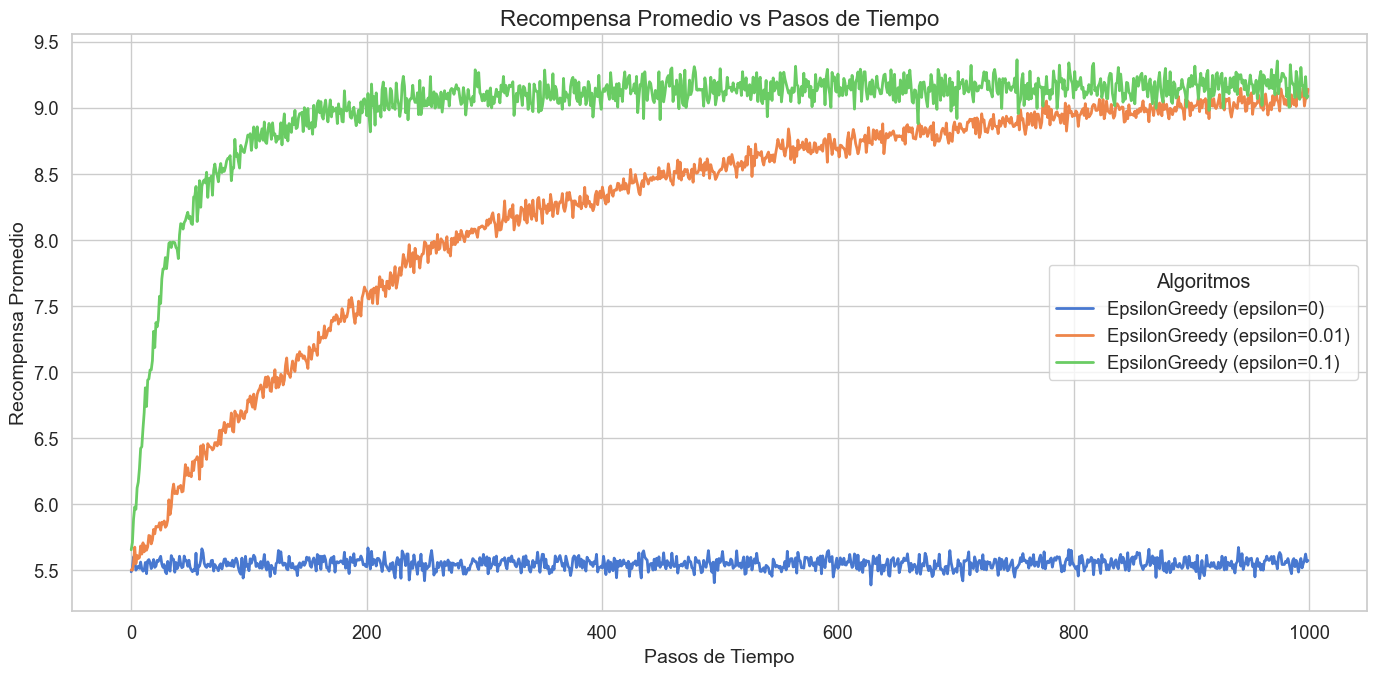

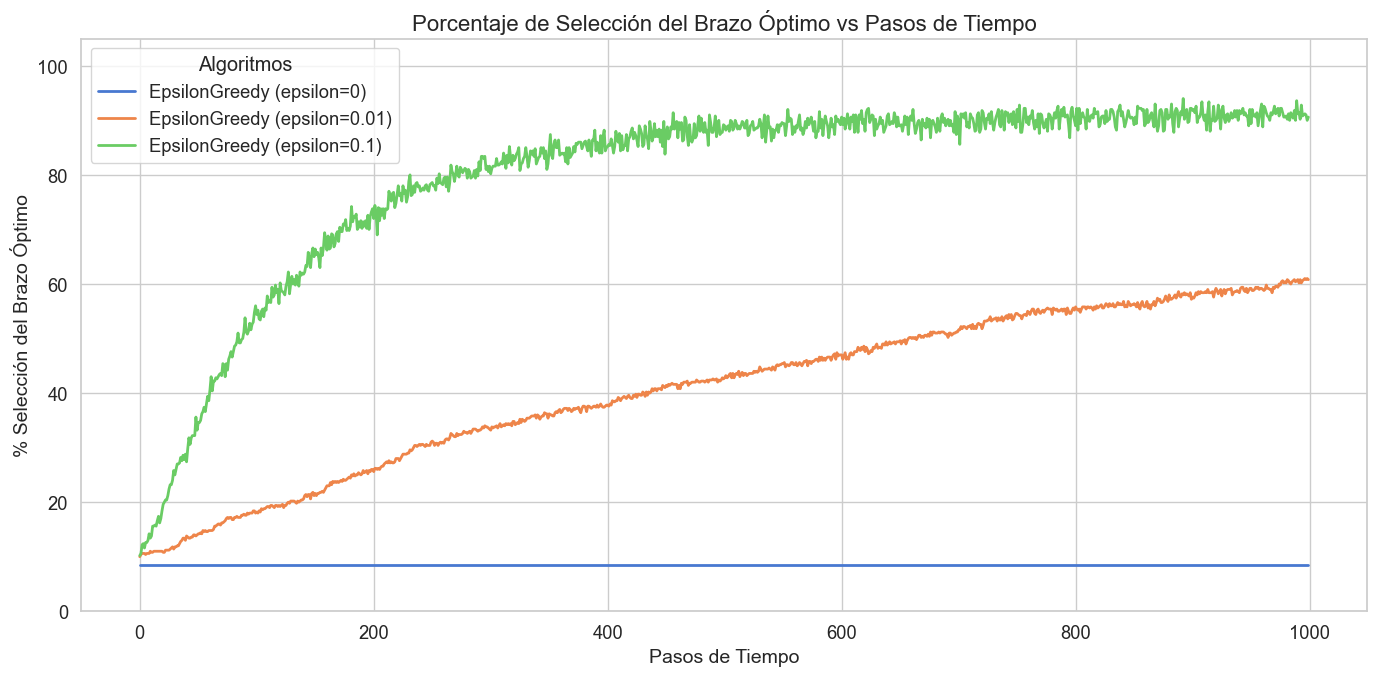

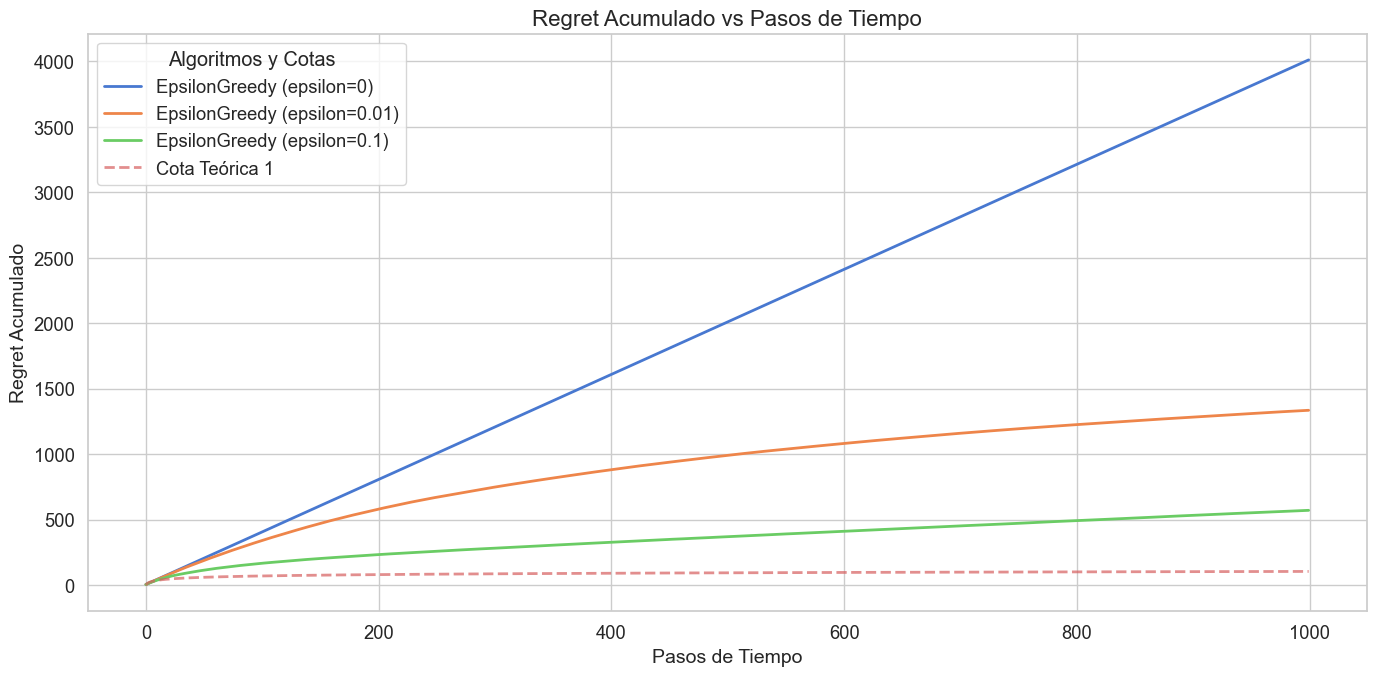

c:\Users\GUILL\OneDrive\Escritorio\VENV\EML\EML\plotting\plotting.py:246: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\GUILL\miniconda3\envs\MIA\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


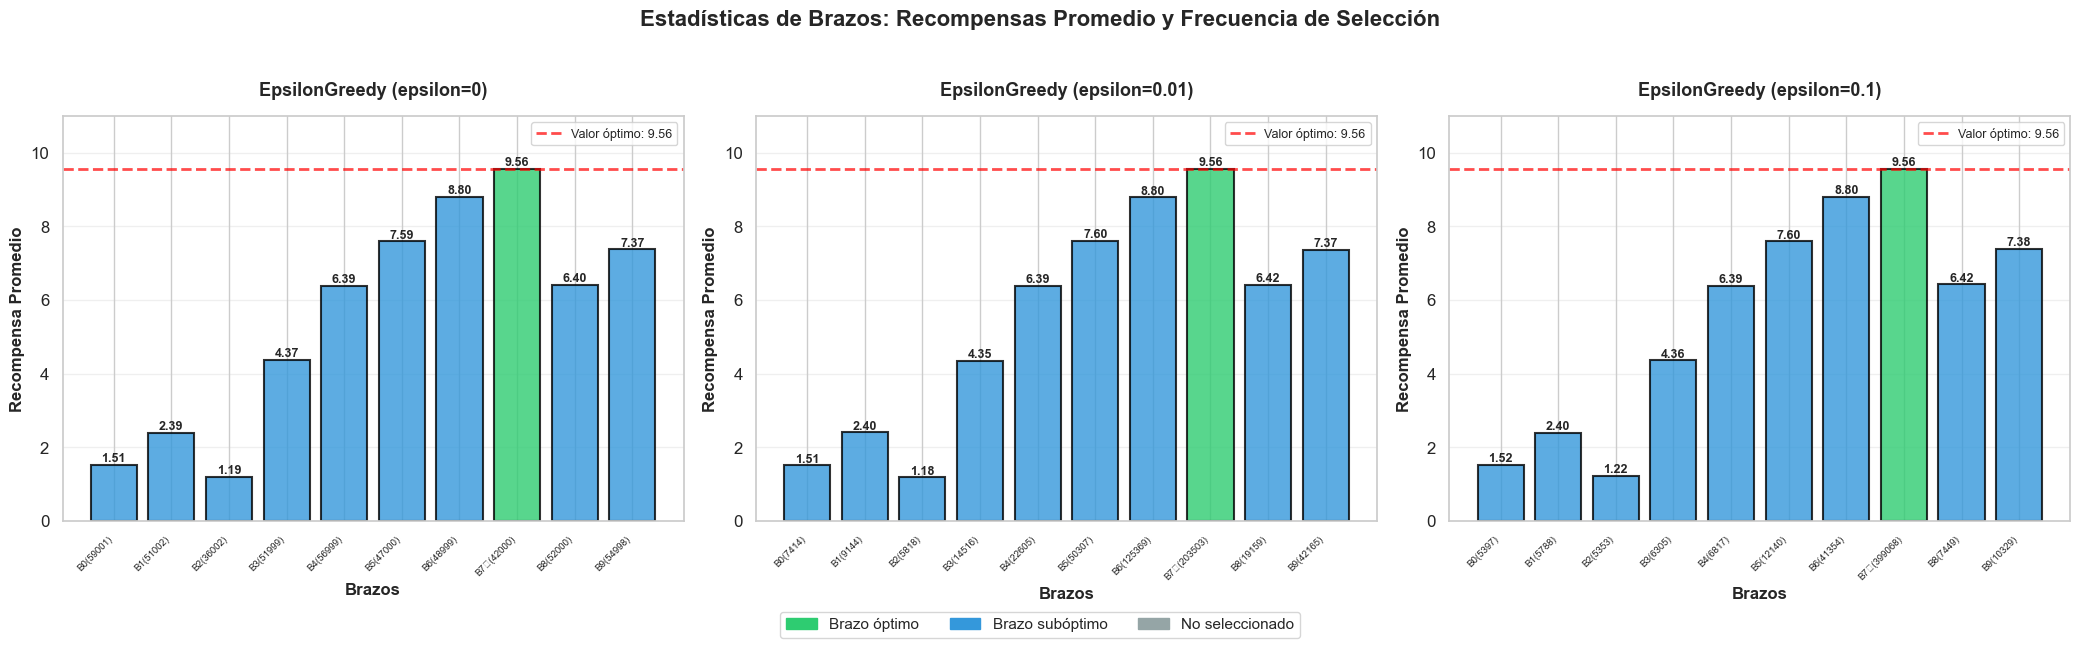

In [22]:

# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)

# Calcular cota teórica para epsilon-greedy
# Regret ≤ C * ln(T) donde C depende del problema
C = 15  # Constante
theoretical_bound = C * np.log(np.arange(1, steps + 1))

plot_regret(steps, regret_accumulated, algorithms, theoretical_bound)
plot_arm_statistics(arm_stats, algorithms, optimal_arm)


## Experimento con epsilon-decaimiento

In [ ]:

# Parámetros del experimento
np.random.seed(seed)  # Fijar la semilla para reproducibilidad

k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Creación del bandit
bandit = Bandit(arms=ArmNormal.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [EpsilonDecaimiento(k=k, epsilon_initial=1.0, epsilon_min=0.1, lambda_=0.001), 
              EpsilonDecaimiento(k=k, epsilon_initial=1.0, epsilon_min=0.1, lambda_=0.01), 
              EpsilonDecaimiento(k=k, epsilon_initial=1.0, epsilon_min=0.1, lambda_=0.1)]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections, regret_accumulated, arm_stats = run_experiment(bandit, algorithms, steps, runs)


Bandit with 10 arms: ArmNormal(mu=1.52, sigma=1.0), ArmNormal(mu=2.4, sigma=1.0), ArmNormal(mu=1.19, sigma=1.0), ArmNormal(mu=4.37, sigma=1.0), ArmNormal(mu=6.39, sigma=1.0), ArmNormal(mu=7.59, sigma=1.0), ArmNormal(mu=8.8, sigma=1.0), ArmNormal(mu=9.56, sigma=1.0), ArmNormal(mu=6.41, sigma=1.0), ArmNormal(mu=7.37, sigma=1.0)
Optimal arm: 8 with expected reward=9.56


### Visualización de los resultados

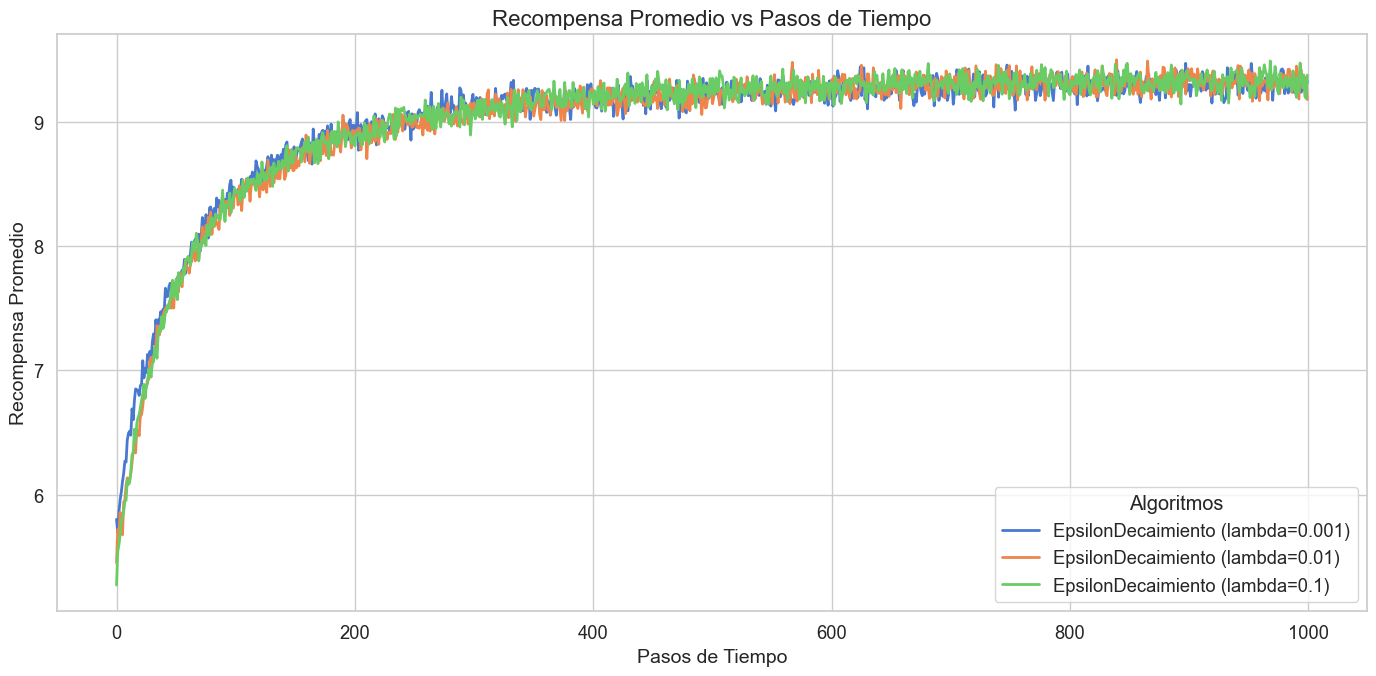

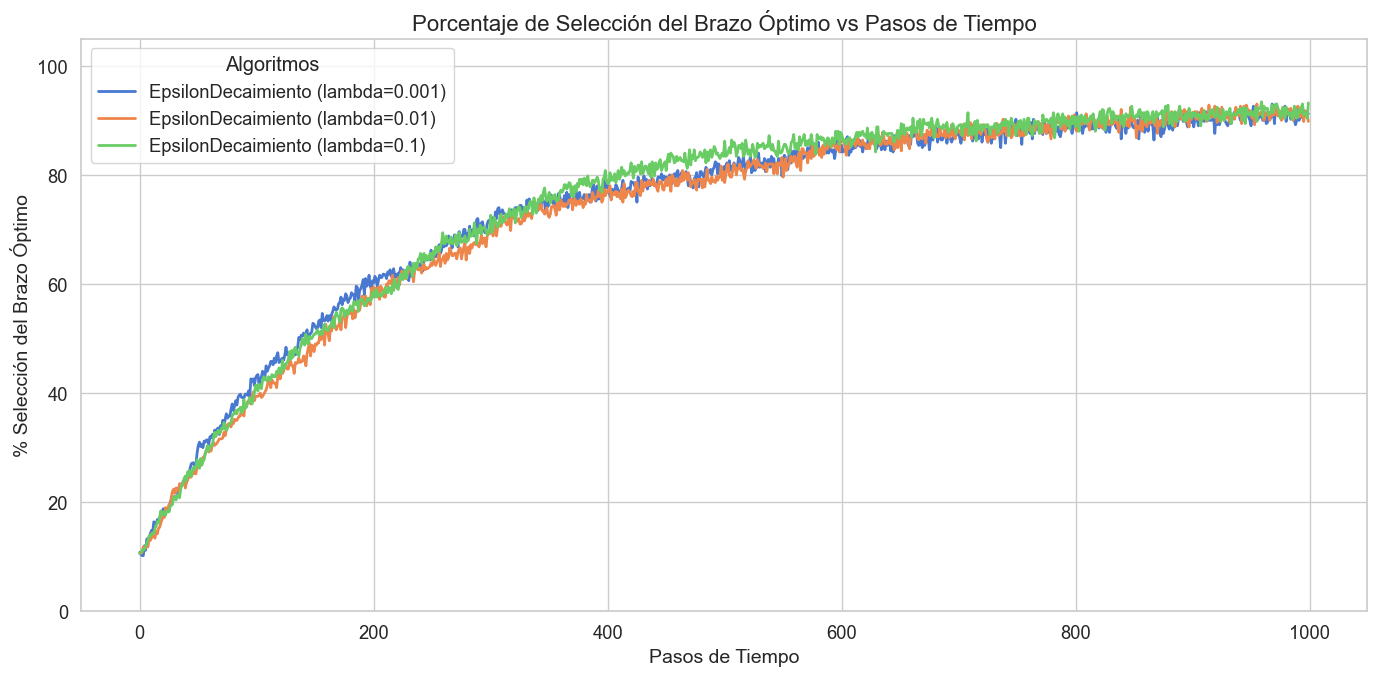

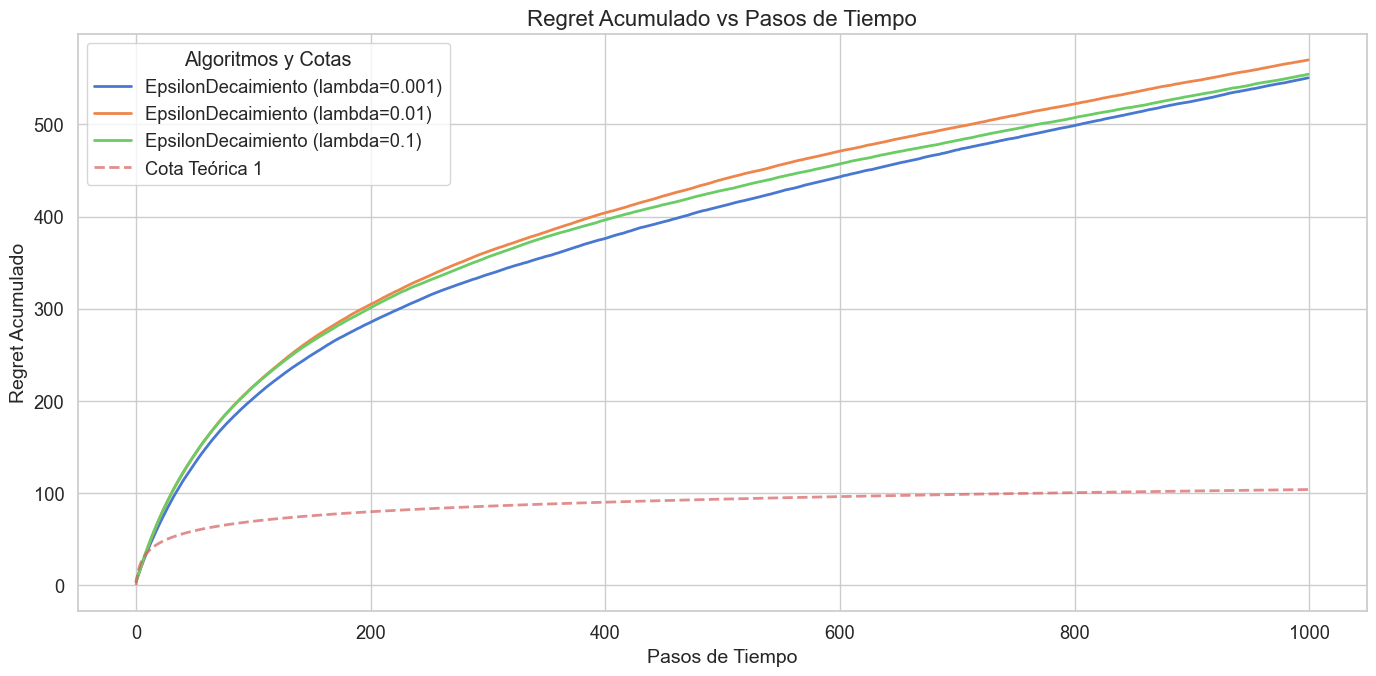

c:\Users\GUILL\OneDrive\Escritorio\VENV\EML\EML\plotting\plotting.py:246: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\GUILL\miniconda3\envs\MIA\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


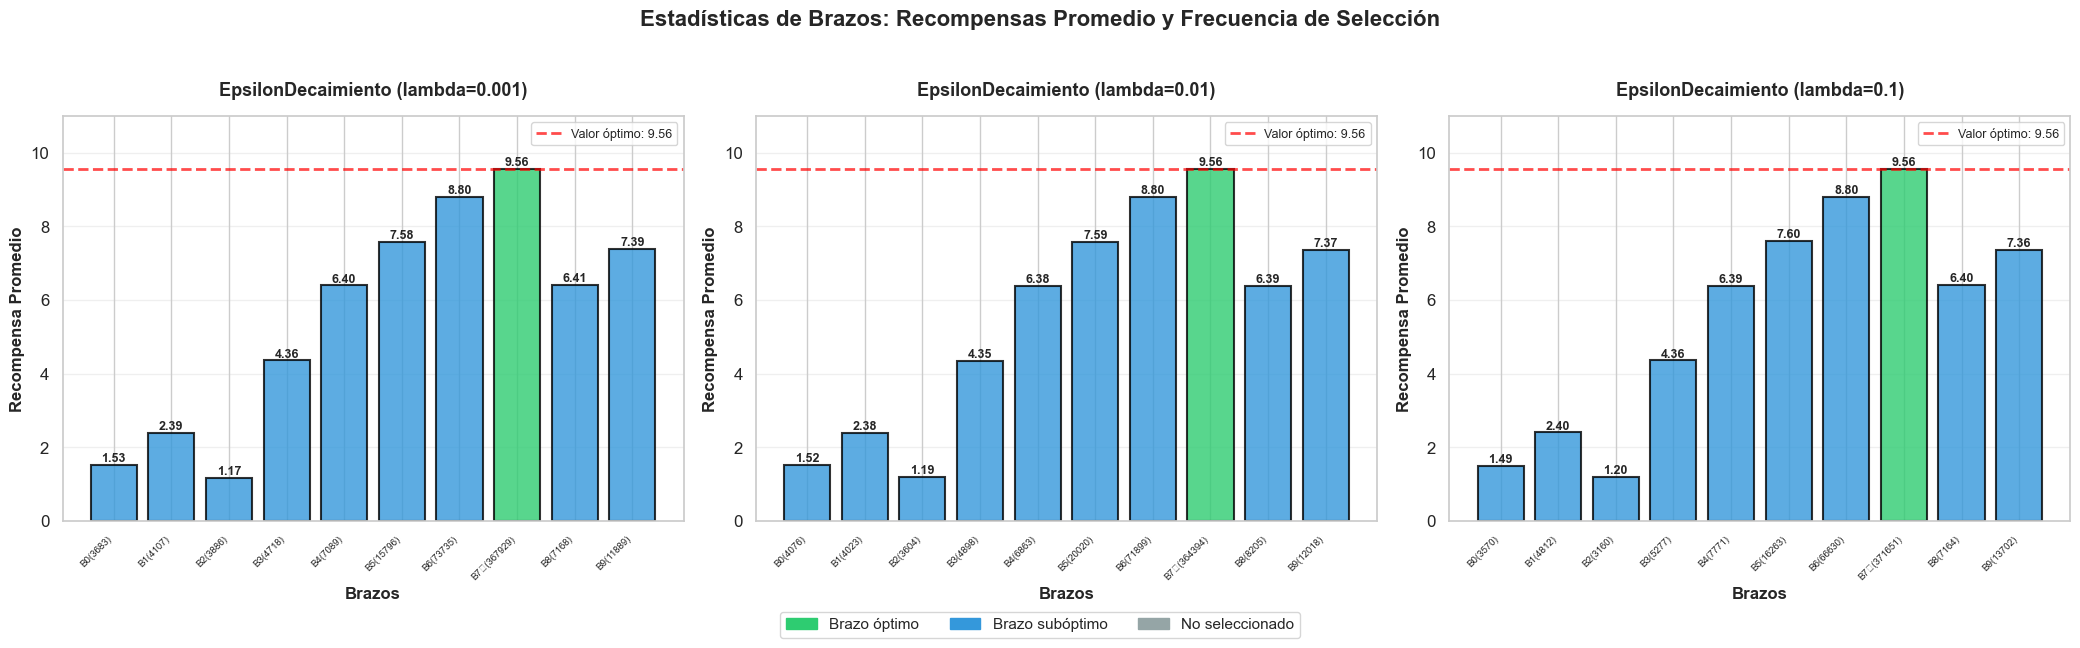

In [ ]:

# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)

# Calcular cota teórica para epsilon-greedy
# Regret ≤ C * ln(T) donde C depende del problema
C = 15  # Constante
theoretical_bound = C * np.log(np.arange(1, steps + 1))

plot_regret(steps, regret_accumulated, algorithms, theoretical_bound)
plot_arm_statistics(arm_stats, algorithms, optimal_arm)


## Experimento con UCB1

In [ ]:

# Parámetros del experimento
np.random.seed(seed)  # Fijar la semilla para reproducibilidad

k = 10  # Número de brazos
steps = 500  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones. No necesita 1000, converge antes

# Creación del bandit
bandit = Bandit(arms=ArmNormal.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [UCB1(k=k, c=0.5),
              UCB1(k=k, c=1),
              UCB1(k=k, c=2)]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections, regret_accumulated, arm_stats = run_experiment(bandit, algorithms, steps, runs)


Bandit with 10 arms: ArmNormal(mu=1.52, sigma=1.0), ArmNormal(mu=2.4, sigma=1.0), ArmNormal(mu=1.19, sigma=1.0), ArmNormal(mu=4.37, sigma=1.0), ArmNormal(mu=6.39, sigma=1.0), ArmNormal(mu=7.59, sigma=1.0), ArmNormal(mu=8.8, sigma=1.0), ArmNormal(mu=9.56, sigma=1.0), ArmNormal(mu=6.41, sigma=1.0), ArmNormal(mu=7.37, sigma=1.0)
Optimal arm: 8 with expected reward=9.56


### Visualización de los resultados

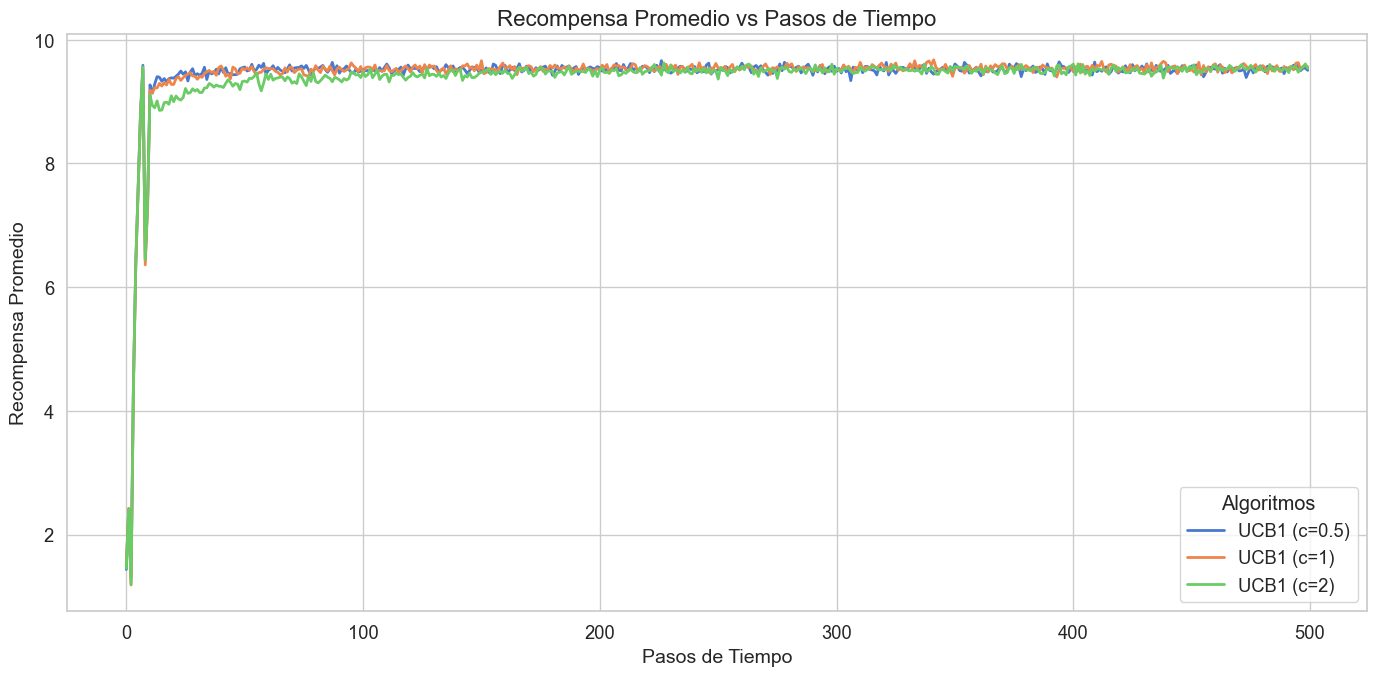

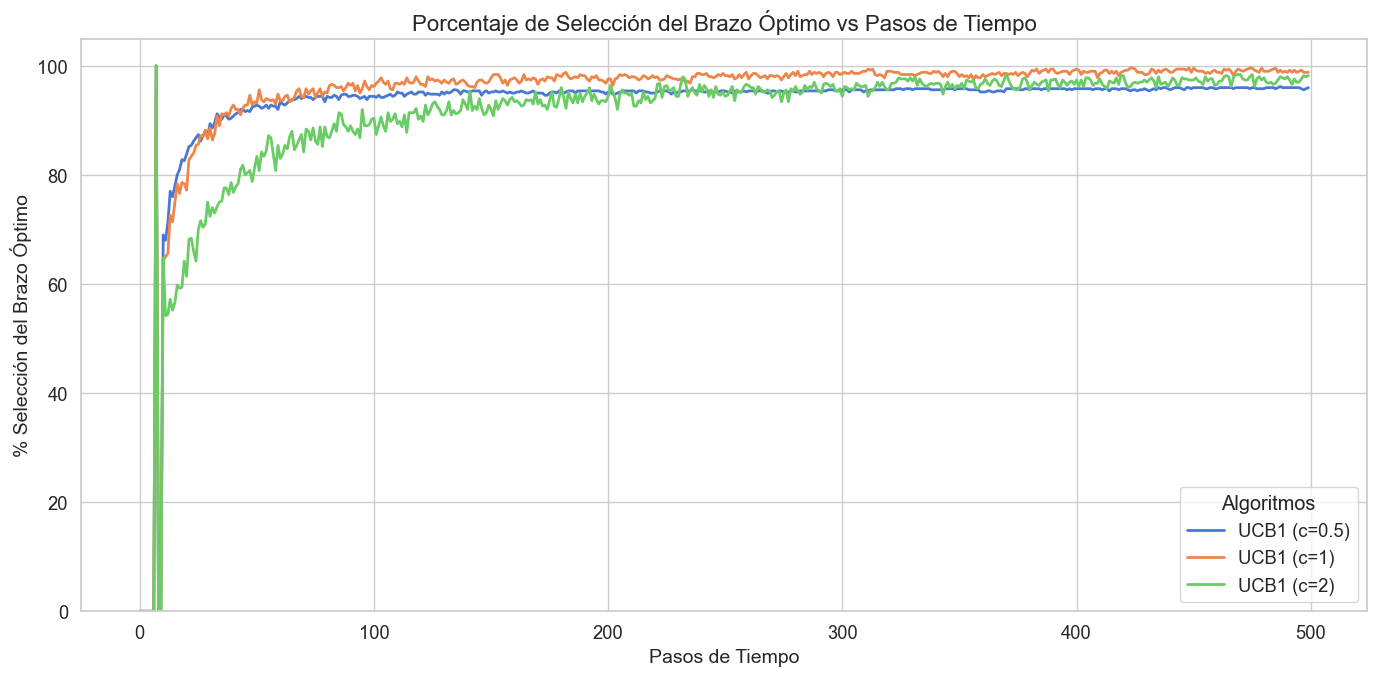

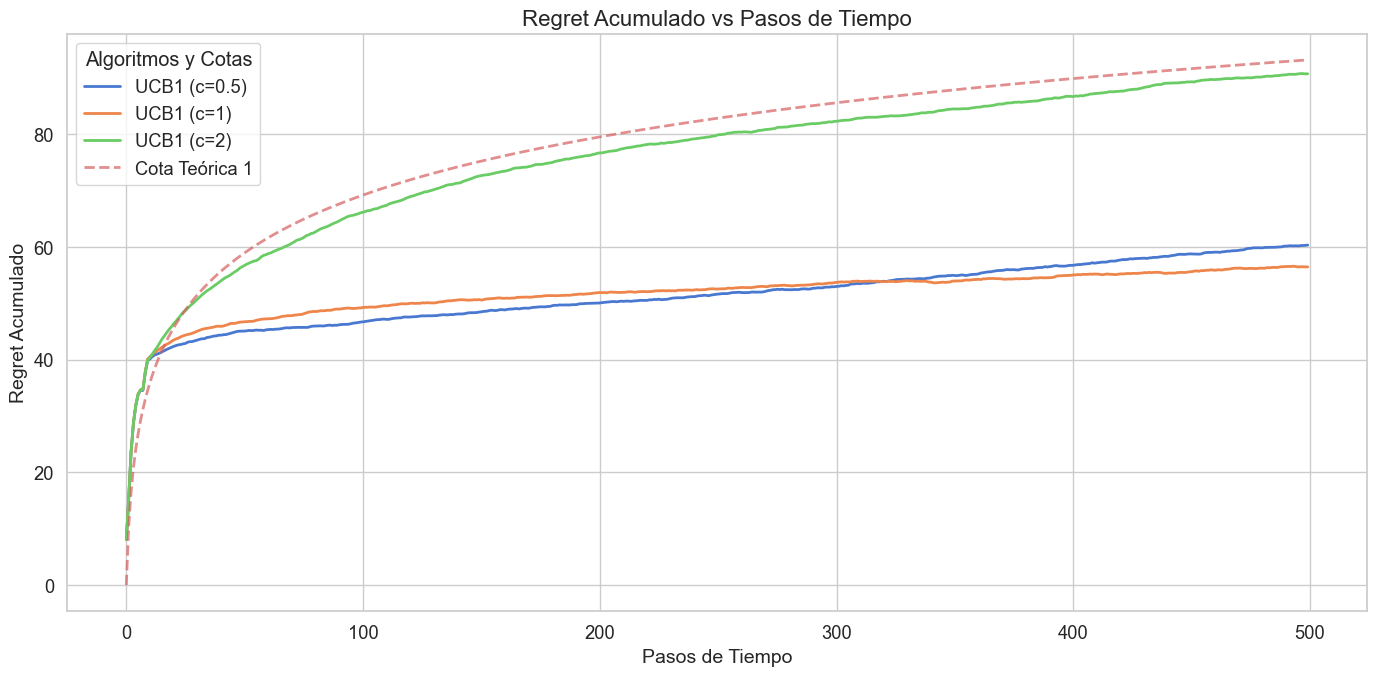

c:\Users\GUILL\OneDrive\Escritorio\VENV\EML\EML\plotting\plotting.py:246: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\GUILL\miniconda3\envs\MIA\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


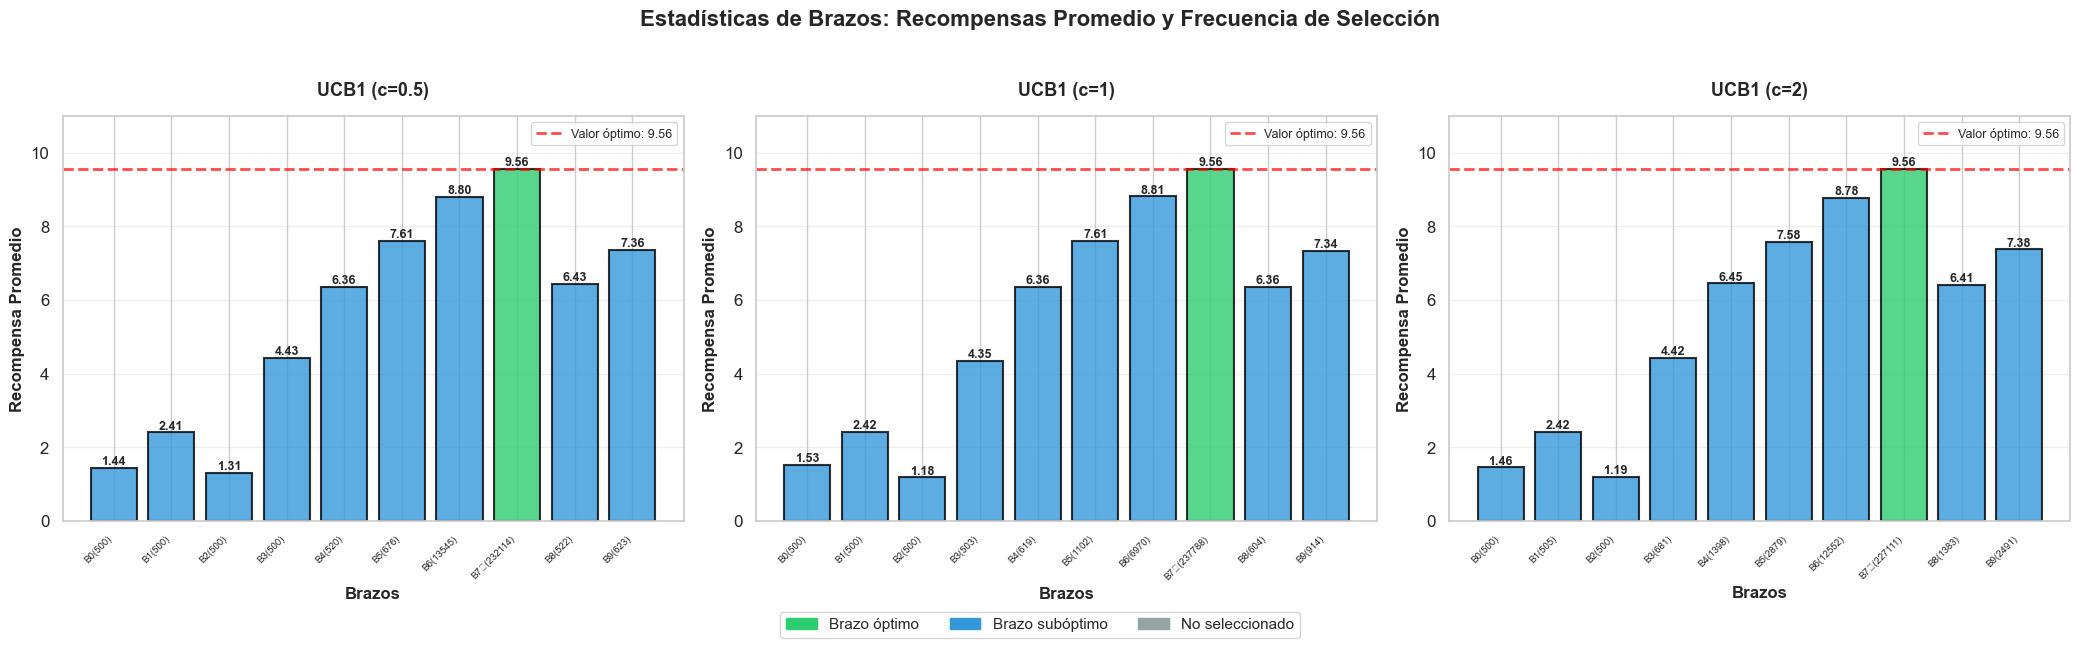

In [18]:

# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)

# Calcular cota teórica para epsilon-greedy
# Regret ≤ C * ln(T) donde C depende del problema
C = 15  # Constante
theoretical_bound = C * np.log(np.arange(1, steps + 1))

plot_regret(steps, regret_accumulated, algorithms, theoretical_bound)
plot_arm_statistics(arm_stats, algorithms, optimal_arm)


## Experimento con Softmax

In [23]:

# Parámetros del experimento
np.random.seed(seed)  # Fijar la semilla para reproducibilidad

k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Creación del bandit
bandit = Bandit(arms=ArmNormal.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [Softmax(k=k, tau=0.1),
              Softmax(k=k, tau=0.5),
              Softmax(k=k, tau=1),
              Softmax(k=k, tau=2)]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections, regret_accumulated, arm_stats = run_experiment(bandit, algorithms, steps, runs)


Bandit with 10 arms: ArmNormal(mu=1.52, sigma=1.0), ArmNormal(mu=2.4, sigma=1.0), ArmNormal(mu=1.19, sigma=1.0), ArmNormal(mu=4.37, sigma=1.0), ArmNormal(mu=6.39, sigma=1.0), ArmNormal(mu=7.59, sigma=1.0), ArmNormal(mu=8.8, sigma=1.0), ArmNormal(mu=9.56, sigma=1.0), ArmNormal(mu=6.41, sigma=1.0), ArmNormal(mu=7.37, sigma=1.0)
Optimal arm: 8 with expected reward=9.56


### Visualización de los resultados

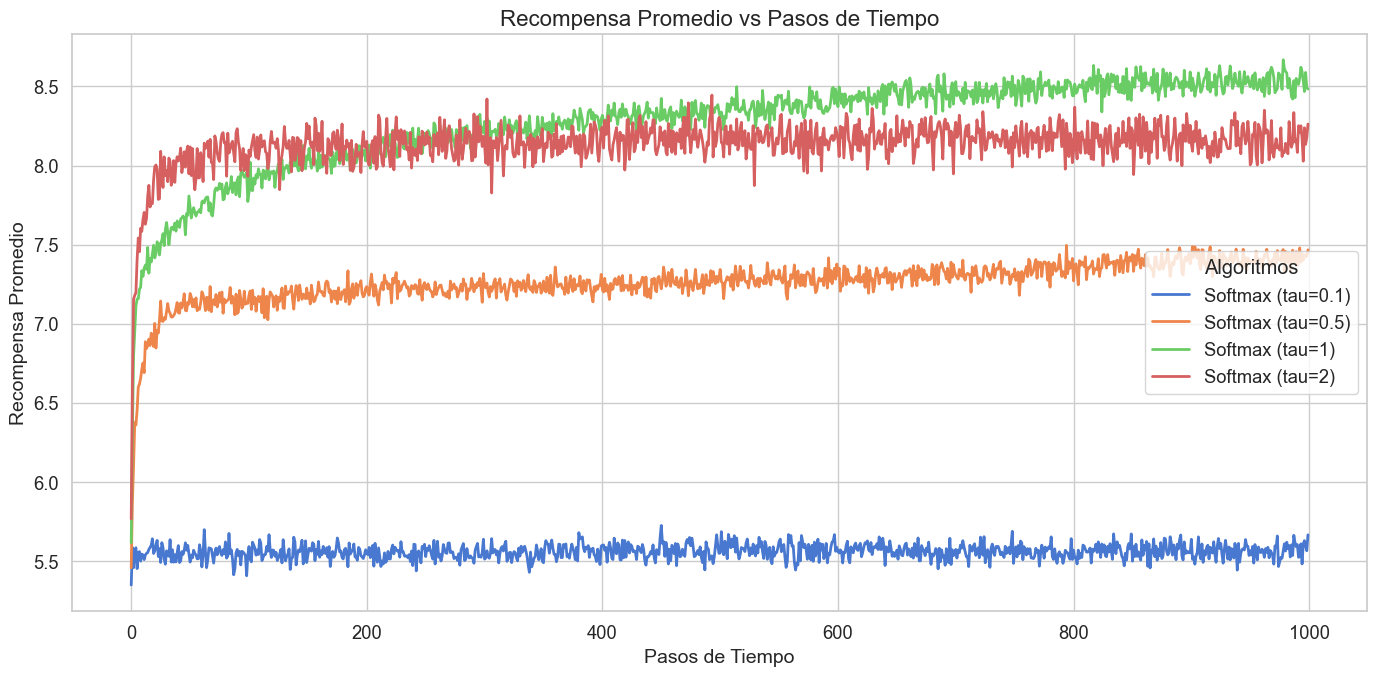

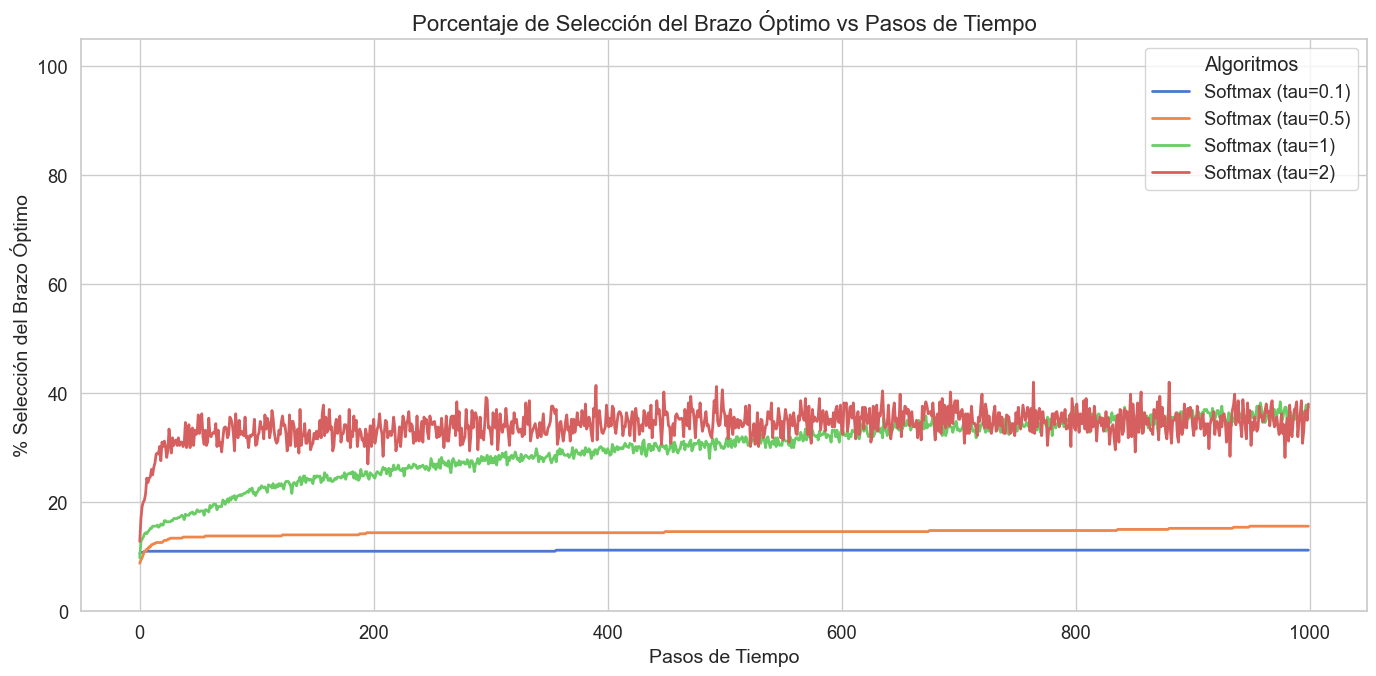

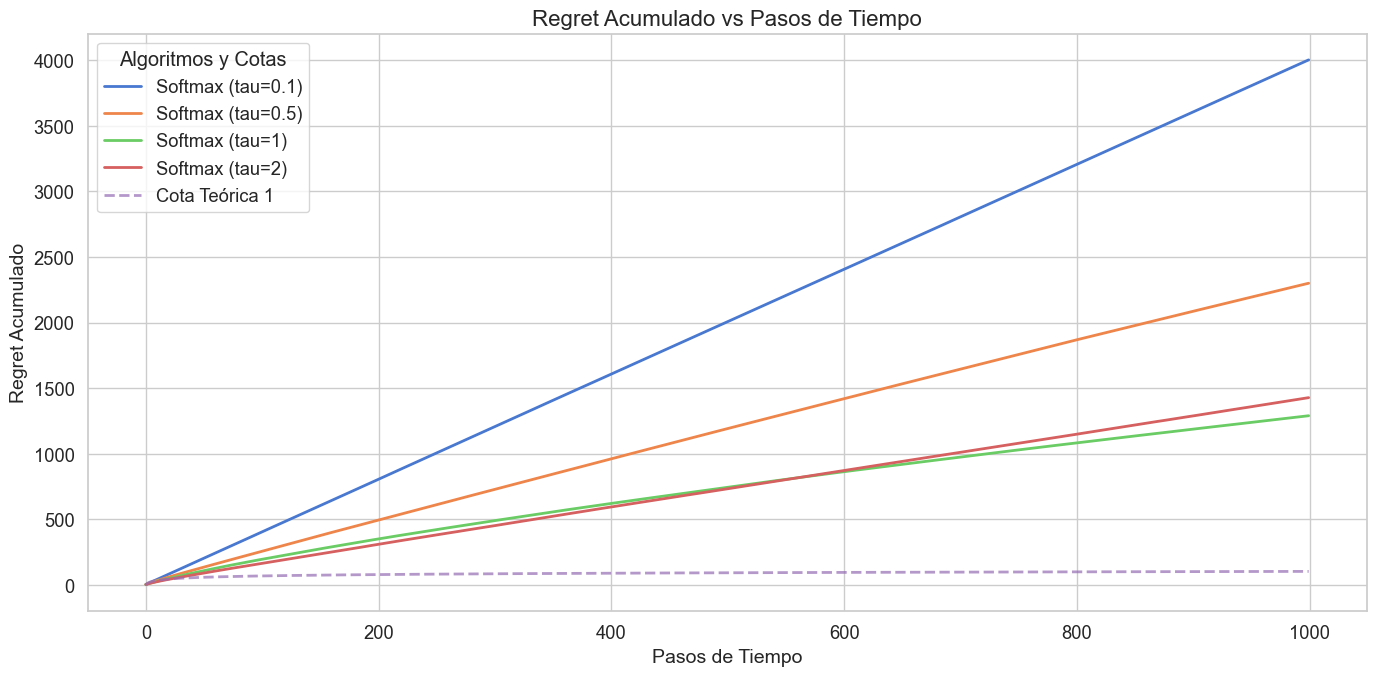

c:\Users\GUILL\OneDrive\Escritorio\VENV\EML\EML\plotting\plotting.py:246: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\GUILL\miniconda3\envs\MIA\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


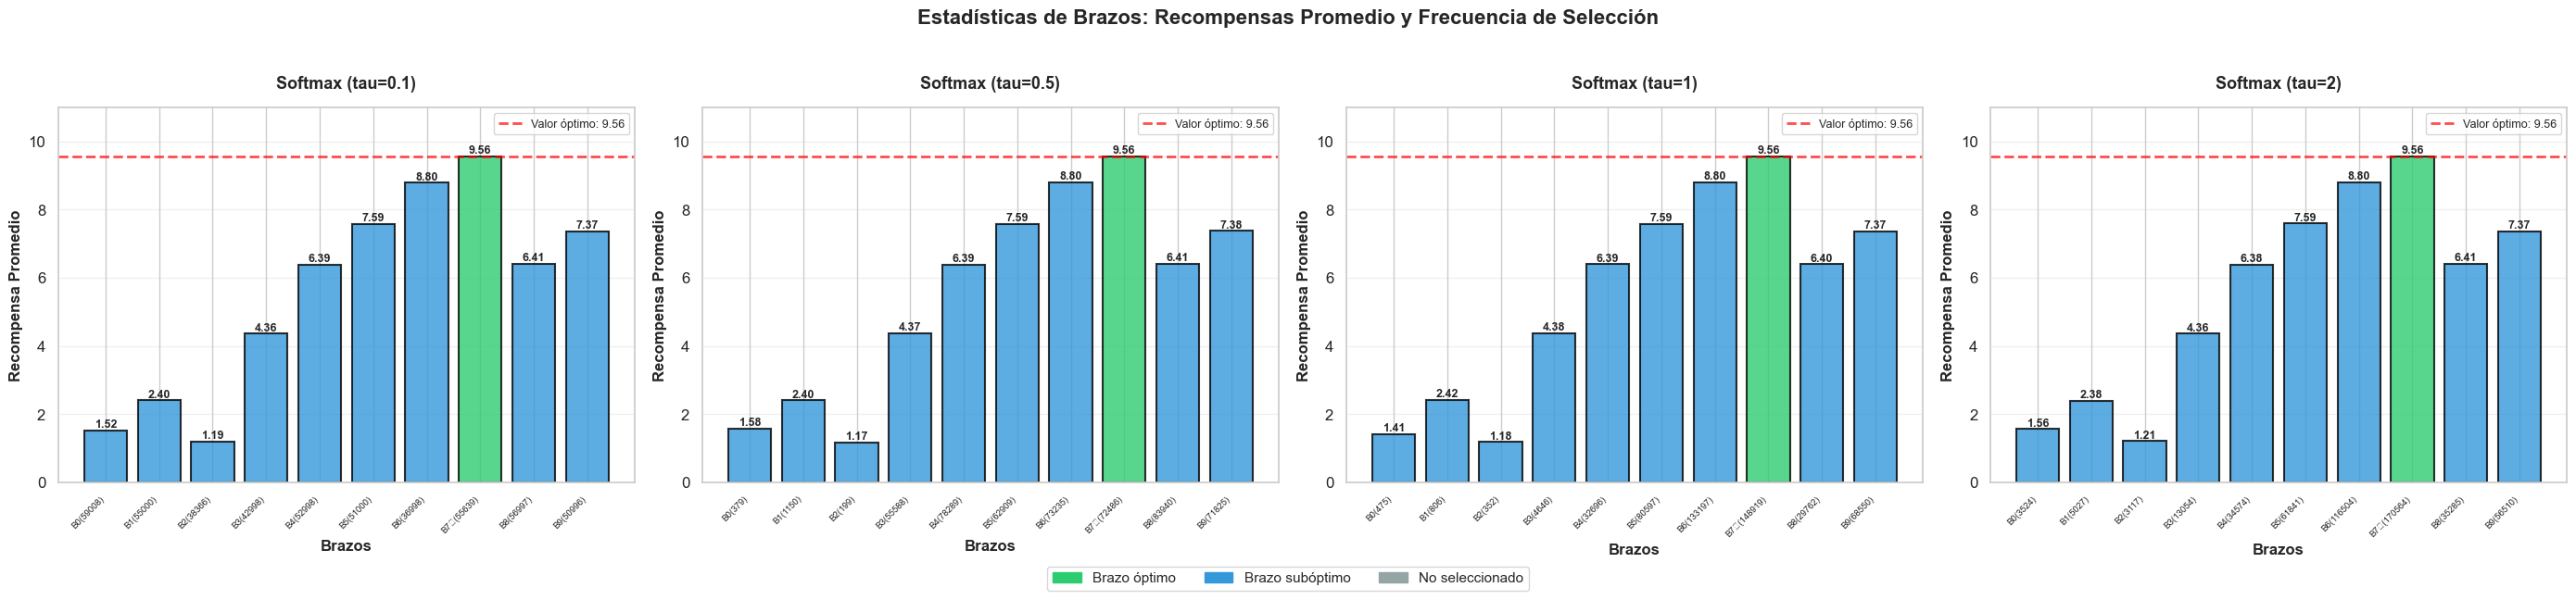

In [24]:

# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)

# Calcular cota teórica para epsilon-greedy
# Regret ≤ C * ln(T) donde C depende del problema
C = 15  # Constante
theoretical_bound = C * np.log(np.arange(1, steps + 1))

plot_regret(steps, regret_accumulated, algorithms, theoretical_bound)
plot_arm_statistics(arm_stats, algorithms, optimal_arm)
